In [3]:
# =========================
# FINAL CLEAN EM (WARMUP + FREEZE VARIANCES)
# =========================

import numpy as np
import pandas as pd
import os 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

EPS = 1e-6
MAX_VAL = 1e6

# =========================
# DATA PREP
# =========================

def prepare_data(df):

    df = df.copy()

    df["SOC_2DIGIT"] = df["SOC_CODE"].astype(str).str[:2]
    soc_counts = df["SOC_2DIGIT"].value_counts()
    df["SOC_F"] = df["SOC_2DIGIT"].where(
        df["SOC_2DIGIT"].isin(soc_counts[soc_counts >= 100].index),
        "OTHER"
    )

    state_counts = df["WORKSITE_STATE"].value_counts()
    df["STATE_F"] = df["WORKSITE_STATE"].where(
        df["WORKSITE_STATE"].isin(state_counts[state_counts >= 100].index),
        "OTHER"
    )

    level_map = {"I":0, "II":1, "III":2, "IV":3}

    L_raw = df["WAGE_LEVEL_CLEAN"].astype(str).str.strip().str.upper()
    L = L_raw.map(level_map)

    # build wage (before filtering so mask is consistent)
    y_raw = np.log(df["wage_ratio"].values)

    # mask: keep only valid rows
    mask = (
    L.notna() &                  # remove unmapped levels
    np.isfinite(y_raw)           # removes inf and -inf
    )

    # apply mask to df
    df = df.loc[mask].copy()

    # now rebuild
    L = L.loc[mask].astype(np.int64).values
    y = np.maximum(y_raw[mask], 0)
    censored = (y == 0)


    
    S = pd.Categorical(df["SOC_F"]).codes
    ST = pd.Categorical(df["STATE_F"]).codes
    E = pd.Categorical(df["EMPLOYER_NAME_CLEAN"]).codes

   

    return {
        "y": y,
        "censored": censored,
        "L": L,
        "E": E,
        "S": S,
        "ST": ST,
        "K": 4,
        "N_E": len(np.unique(E)),
        "N_S": len(np.unique(S)),
        "N_ST": len(np.unique(ST))
    }

# =========================
# E STEP
# =========================

def truncated_normal_moments(mu, sigma):

    sigma = np.maximum(sigma, EPS)
    alpha = np.clip(-mu / sigma, -10, 10)

    phi = stats.norm.pdf(alpha)
    Phi = np.clip(stats.norm.cdf(alpha), 1e-10, 1.0)

    ratio = np.clip(phi / Phi, -MAX_VAL, MAX_VAL)

    E1 = mu - sigma * ratio
    E2 = mu**2 + sigma**2 - sigma * (mu + sigma * ratio) * ratio

    return E1, E2

def e_step(y, censored, mu, sigma):

    y_star = y.copy()
    y_star2 = y**2

    if censored.any():
        E1, E2 = truncated_normal_moments(mu[censored], sigma)
        y_star[censored] = E1
        y_star2[censored] = E2

    return y_star, y_star2

# =========================
# SAFE VARIANCE UPDATES
# =========================

def update_sigma(alpha):
    return max((np.sum(alpha**2) + 0.1) / (len(alpha) + 2), 1e-4)

def update_sigma2(resid2):
    return max((np.sum(resid2) + 0.1) / (len(resid2) + 2), 1e-4)

def damp(old, new, w=0.1):
    return (1-w)*old + w*new

# =========================
# M STEP (MEANS ONLY)
# =========================

def m_step(y_star, y_star2, L, E, S, ST,
           gamma, alpha, delta, eta,
           sigma2, sigma_E2, sigma_L2, sigma_S2, sigma_ST2):

    n = len(y_star)

    lam_L = min(sigma2 / sigma_L2, MAX_VAL)
    lam_E = min(sigma2 / sigma_E2, MAX_VAL)
    lam_S = min(sigma2 / sigma_S2, MAX_VAL)
    lam_ST = min(sigma2 / sigma_ST2, MAX_VAL)

    K, N_E, N_S, N_ST = len(gamma), len(alpha), len(delta), len(eta)

    n_L = np.bincount(L, minlength=K)
    n_E = np.bincount(E, minlength=N_E)
    n_S = np.bincount(S, minlength=N_S)
    n_ST = np.bincount(ST, minlength=N_ST)

    Sy_L = np.bincount(L, weights=y_star, minlength=K)
    Sy_E = np.bincount(E, weights=y_star, minlength=N_E)
    Sy_S = np.bincount(S, weights=y_star, minlength=N_S)
    Sy_ST = np.bincount(ST, weights=y_star, minlength=N_ST)

    Sy_total = y_star.sum()

    for _ in range(30):

        beta0 = (Sy_total - (gamma[L] + alpha[E] + delta[S] + eta[ST]).sum()) / n

        gamma = (Sy_L - np.bincount(L, weights=alpha[E]+delta[S]+eta[ST], minlength=K) - n_L*beta0) / (n_L + lam_L)
        alpha = (Sy_E - np.bincount(E, weights=gamma[L]+delta[S]+eta[ST], minlength=N_E) - n_E*beta0) / (n_E + lam_E)
        delta = (Sy_S - np.bincount(S, weights=gamma[L]+alpha[E]+eta[ST], minlength=N_S) - n_S*beta0) / (n_S + lam_S)
        eta   = (Sy_ST - np.bincount(ST, weights=gamma[L]+alpha[E]+delta[S], minlength=N_ST) - n_ST*beta0) / (n_ST + lam_ST)

    mu = beta0 + gamma[L] + alpha[E] + delta[S] + eta[ST]

    resid2 = np.clip(y_star2 - 2*y_star*mu + mu**2, 0, MAX_VAL)
    sigma2 = update_sigma2(resid2)

    return beta0, gamma, alpha, delta, eta, sigma2, mu

# =========================
# LOG LIKELIHOOD
# =========================

def observed_ll(y, censored, mu, sigma):

    sigma = max(sigma, 1e-4)

    ll = 0
    if (~censored).any():
        ll += stats.norm.logpdf(y[~censored], mu[~censored], sigma).sum()

    if censored.any():
        ll += np.log(np.clip(stats.norm.cdf(0, mu[censored], sigma), 1e-10, 1)).sum()

    return ll

# =========================
# FIT MODEL
# =========================

def fit_model_l(data, max_iter=50):

    y, censored = data['y'], data['censored']
    L, E, S, ST = data['L'], data['E'], data['S'], data['ST']


    print(L.dtype, E.dtype, S.dtype, ST.dtype)
    print(type(L[0]), L[:5])
    
    gamma = np.zeros(data['K'])
    alpha = np.zeros(data['N_E'])
    delta = np.zeros(data['N_S'])
    eta   = np.zeros(data['N_ST'])

    beta0 = np.mean(y)

    sigma2 = 1.0
    sigma_E2 = sigma_L2 = sigma_S2 = sigma_ST2 = 0.1

    lls = []
    history = []

    for it in range(max_iter):

        mu = beta0 + gamma[L] + alpha[E] + delta[S] + eta[ST]

        y_star, y_star2 = e_step(y, censored, mu, np.sqrt(sigma2))

        beta0, gamma, alpha, delta, eta, sigma2, mu = m_step(
            y_star, y_star2, L, E, S, ST,
            gamma, alpha, delta, eta,
            sigma2, sigma_E2, sigma_L2, sigma_S2, sigma_ST2
        )

        # Warmup → Freeze
        if it < 10:
            sigma_E2 = damp(sigma_E2, update_sigma(alpha))
            sigma_L2 = damp(sigma_L2, update_sigma(gamma))
            sigma_S2 = damp(sigma_S2, update_sigma(delta))
            sigma_ST2 = damp(sigma_ST2, update_sigma(eta))

        ll = observed_ll(y, censored, mu, np.sqrt(sigma2))
        lls.append(ll)

        history.append({
            "sigma": np.sqrt(sigma2),
            "sigma_E": np.sqrt(sigma_E2),
            "sigma_L": np.sqrt(sigma_L2),
            "sigma_S": np.sqrt(sigma_S2),
            "sigma_ST": np.sqrt(sigma_ST2)
        })

        print(f"iter {it}: ll={ll:.2f}")

        if it > 2 and abs(lls[-1] - lls[-2]) < 1:
            break

    return {
        "beta0": beta0,
        "gamma": gamma,
        "alpha": alpha,
        "delta": delta,
        "eta": eta,
        "sigma": np.sqrt(sigma2),
        "lls": lls,
        "history": history,
        "data": data
    }

# =========================
# DIAGNOSTICS
# =========================

def plot_results(result):

    data = result["data"]
    mu = (result["beta0"]
          + result["gamma"][data["L"]]
          + result["alpha"][data["E"]]
          + result["delta"][data["S"]]
          + result["eta"][data["ST"]])

    sigma = result["sigma"]
    y = data["y"]

    fig = plt.figure(figsize=(16,10))
    gs = gridspec.GridSpec(2,4)

    plt.subplot(gs[0,0]); plt.plot(result["lls"]); plt.title("LL")
    plt.subplot(gs[0,1]); plt.hist(result["alpha"], bins=40); plt.title("Employer")
    plt.subplot(gs[0,2]); plt.bar(range(4), result["gamma"]); plt.title("Level")
    plt.subplot(gs[0,3]); plt.hist(result["delta"], bins=30); plt.title("SOC")

    plt.subplot(gs[1,0]); plt.hist(result["eta"], bins=30); plt.title("State")

    plt.subplot(gs[1,1])
    y_sim = np.maximum(np.random.normal(mu, sigma), 0)
    plt.hist(y[y>0], bins=50, density=True, alpha=0.5)
    plt.hist(y_sim[y_sim>0], bins=50, density=True, alpha=0.5)
    plt.title("Posterior Predictive")

    plt.subplot(gs[1,2])
    stats.probplot((y[y>0]-mu[y>0])/sigma, plot=plt)

    plt.subplot(gs[1,3])
    plt.plot(np.diff(result["lls"]))
    plt.axhline(0)

    plt.tight_layout()
    plt.show()

# =========================
# RUN
# =========================


if __name__ == "__main__":

    df = pd.read_parquet("final_filtered.parquet")

    df = df[(df.wage_ratio < 2) & (df.wage_ratio > 0.5)]
    df = df[df["EMPLOYER_NAME_CLEAN"].map(df["EMPLOYER_NAME_CLEAN"].value_counts()) >= 100]

    data = prepare_data(df)

    result = fit_model_l(data)

int64 int16 int8 int8
<class 'numpy.int64'> [0 3 0 3 2]
iter 0: ll=353574.26
iter 1: ll=898894.00
iter 2: ll=1044466.10
iter 3: ll=1083493.33
iter 4: ll=1098680.14
iter 5: ll=1108681.85
iter 6: ll=1117280.82
iter 7: ll=1125055.76
iter 8: ll=1131983.87
iter 9: ll=1137994.48
iter 10: ll=1143046.19
iter 11: ll=1147122.78
iter 12: ll=1150240.47
iter 13: ll=1152455.01
iter 14: ll=1153872.87
iter 15: ll=1154643.09
iter 16: ll=1154935.86
iter 17: ll=1154915.97
iter 18: ll=1154721.33
iter 19: ll=1154452.74
iter 20: ll=1154174.42
iter 21: ll=1153921.28
iter 22: ll=1153708.06
iter 23: ll=1153537.44
iter 24: ll=1153405.86
iter 25: ll=1153307.30
iter 26: ll=1153235.28
iter 27: ll=1153183.88
iter 28: ll=1153148.12
iter 29: ll=1153124.00
iter 30: ll=1153108.39
iter 31: ll=1153098.94
iter 32: ll=1153093.86
iter 33: ll=1153091.86
iter 34: ll=1153091.97


In [8]:
# =============================================================================
# HURDLE MODEL: Bernoulli censoring + Gamma positive log wage ratio
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression, GammaRegressor
from scipy import sparse

EPS = 1e-8


def prepare_data_hurdle(df):
    df = df.copy()

    df["SOC_2DIGIT"] = df["SOC_CODE"].astype(str).str[:2]

    soc_counts = df["SOC_2DIGIT"].value_counts()
    df["SOC_F"] = df["SOC_2DIGIT"].where(
        df["SOC_2DIGIT"].isin(soc_counts[soc_counts >= 100].index),
        "OTHER"
    )

    state_counts = df["WORKSITE_STATE"].value_counts()
    df["STATE_F"] = df["WORKSITE_STATE"].where(
        df["WORKSITE_STATE"].isin(state_counts[state_counts >= 100].index),
        "OTHER"
    )

    level_map = {"I": 0, "II": 1, "III": 2, "IV": 3}

    L_raw = df["WAGE_LEVEL_CLEAN"].astype(str).str.strip().str.upper()
    L = L_raw.map(level_map)

    y_raw = np.log(df["wage_ratio"].values)

    mask = (
        L.notna()
        & np.isfinite(y_raw)
    )

    df = df.loc[mask].copy()

    L = L.loc[mask].astype(np.int64).values
    y = np.maximum(y_raw[mask], 0.0)
    censored = y == 0
    positive = ~censored

    S_cat = pd.Categorical(df["SOC_F"])
    ST_cat = pd.Categorical(df["STATE_F"])
    E_cat = pd.Categorical(df["EMPLOYER_NAME_CLEAN"])

    S = S_cat.codes.astype(np.int64)
    ST = ST_cat.codes.astype(np.int64)
    E = E_cat.codes.astype(np.int64)

    return {
        "df": df,
        "y": y,
        "censored": censored,
        "positive": positive,
        "L": L,
        "E": E,
        "S": S,
        "ST": ST,
        "K": 4,
        "N_E": len(E_cat.categories),
        "N_S": len(S_cat.categories),
        "N_ST": len(ST_cat.categories),
        "E_categories": list(E_cat.categories),
        "S_categories": list(S_cat.categories),
        "ST_categories": list(ST_cat.categories),
        "N": len(df)
    }


# =============================================================================
# DESIGN MATRIX
# =============================================================================

def make_design_matrix(data, idx=None, encoder=None, fit_encoder=False):
    """
    Sparse one-hot design matrix for:
        wage level + employer + SOC + state

    We do not drop a reference category because the L2 penalty stabilizes the fit.
    This makes coefficient extraction easier.
    """
    if idx is None:
        idx = np.arange(data["N"])

    X_raw = np.column_stack([
        data["L"][idx],
        data["E"][idx],
        data["S"][idx],
        data["ST"][idx],
    ])

    categories = [
        np.arange(data["K"]),
        np.arange(data["N_E"]),
        np.arange(data["N_S"]),
        np.arange(data["N_ST"]),
    ]

    if encoder is None:
        try:
            encoder = OneHotEncoder(
                categories=categories,
                sparse_output=True,
                handle_unknown="ignore"
            )
        except TypeError:
            # for older sklearn versions
            encoder = OneHotEncoder(
                categories=categories,
                sparse=True,
                handle_unknown="ignore"
            )

    if fit_encoder:
        X = encoder.fit_transform(X_raw)
    else:
        X = encoder.transform(X_raw)

    return X, encoder


# =============================================================================
# FIT HURDLE MODEL
# =============================================================================

def fit_hurdle_model(
    data,
    logistic_C=1.0,
    gamma_alpha=1.0,
    max_iter=1000,
    verbose=True
):
    """
    Fits two separate penalized models.

    Part 1: censoring / threshold bunching model
        censored_i ~ Bernoulli(q_i)
        logit(q_i) = additive effects

    Part 2: positive log wage ratio model
        y_i | y_i > 0 ~ Gamma(mean=m_i)
        log(m_i) = additive effects

    Parameters
    ----------
    logistic_C:
        Inverse L2 penalty strength for LogisticRegression.
        Smaller C = stronger shrinkage.

    gamma_alpha:
        L2 penalty strength for GammaRegressor.
        Larger alpha = stronger shrinkage.
    """

    y = data["y"]
    censored = data["censored"].astype(int)
    pos_idx = np.where(data["positive"])[0]

    # Full design for censoring model
    X_all, encoder = make_design_matrix(data, fit_encoder=True)

    # Positive-only design for Gamma model
    X_pos, _ = make_design_matrix(data, idx=pos_idx, encoder=encoder, fit_encoder=False)
    y_pos = np.maximum(y[pos_idx], EPS)

    # -------------------------------------------------------------------------
    # 1. Bernoulli hurdle model for y == 0
    # -------------------------------------------------------------------------
    logit_model = LogisticRegression(
        penalty="l2",
        C=logistic_C,
        fit_intercept=True,
        solver="lbfgs",
        max_iter=max_iter
    )
    logit_model.fit(X_all, censored)

    q_hat = logit_model.predict_proba(X_all)[:, 1]

    # -------------------------------------------------------------------------
    # 2. Gamma model for y > 0
    # -------------------------------------------------------------------------
    gamma_model = GammaRegressor(
        alpha=gamma_alpha,
        fit_intercept=True,
        max_iter=max_iter
    )
    gamma_model.fit(X_pos, y_pos)

    m_hat_all = gamma_model.predict(X_all)
    m_hat_pos = gamma_model.predict(X_pos)

    # Gamma variance convention:
    #     Var(Y_i | positive) = phi * m_i^2
    # so shape = 1 / phi.
    pearson = ((y_pos - m_hat_pos) / np.maximum(m_hat_pos, EPS)) ** 2
    phi_hat = max(np.mean(pearson), EPS)
    shape_hat = 1.0 / phi_hat

    if verbose:
        obs_cens = censored.mean()
        pred_cens = q_hat.mean()
        print("Hurdle model fitted.")
        print(f"Observed censoring rate:  {obs_cens:.4f}")
        print(f"Predicted censoring rate: {pred_cens:.4f}")
        print(f"Gamma phi:                {phi_hat:.4f}")
        print(f"Gamma shape:              {shape_hat:.4f}")
        print(f"Mean positive y observed: {y_pos.mean():.4f}")
        print(f"Mean positive y fitted:   {m_hat_pos.mean():.4f}")

    return {
        "logit_model": logit_model,
        "gamma_model": gamma_model,
        "encoder": encoder,
        "q_hat": q_hat,
        "m_hat": m_hat_all,
        "phi": phi_hat,
        "shape": shape_hat,
        "data": data,
        "pos_idx": pos_idx,
        "logistic_C": logistic_C,
        "gamma_alpha": gamma_alpha,
    }


# =============================================================================
# SIMULATE POSTERIOR / PREDICTIVE REPLICATES
# =============================================================================

def simulate_yrep_hurdle(result, n_sim=50, rng=None):
    """
    Simulate replicated datasets from the hurdle model.

    Important:
        Zeros ONLY come from the Bernoulli hurdle.
        Positive values ONLY come from the Gamma positive model.

    """
    if rng is None:
        rng = np.random.default_rng(42)

    q = result["q_hat"]
    m = np.maximum(result["m_hat"], EPS)
    shape = result["shape"]

    n = len(q)
    y_rep = np.zeros((n_sim, n))

    for s in range(n_sim):
        is_zero = rng.random(n) < q

        # Gamma parameterization:
        # mean = shape * scale,
        # so scale = mean / shape.
        y_pos = rng.gamma(
            shape=shape,
            scale=m / shape
        )

        y_rep[s] = np.where(is_zero, 0.0, y_pos)

    return y_rep


# =============================================================================
# BASIC PPC DIAGNOSTICS
# =============================================================================

def ppc_hurdle_summary(result, n_sim=50, rng=None):
    data = result["data"]
    y = data["y"]
    censored = data["censored"]
    E = data["E"]
    employer_names = data["E_categories"]

    y_rep = simulate_yrep_hurdle(result, n_sim=n_sim, rng=rng)

    # -------------------------------------------------------------------------
    # Aggregate censoring
    # -------------------------------------------------------------------------
    obs_cens = censored.mean()
    rep_cens = (y_rep == 0).mean(axis=1)

    print("\nAggregate censoring PPC")
    print("------------------------")
    print(f"Observed censoring rate:     {obs_cens:.4f}")
    print(f"Replicated mean:             {rep_cens.mean():.4f}")
    print(f"Replicated 90% interval:     "
          f"[{np.quantile(rep_cens, 0.05):.4f}, {np.quantile(rep_cens, 0.95):.4f}]")

    # -------------------------------------------------------------------------
    # Employer-level censoring intervals
    # -------------------------------------------------------------------------
    n_E = data["N_E"]
    obs_emp_rate = np.zeros(n_E)
    lo_emp = np.zeros(n_E)
    hi_emp = np.zeros(n_E)
    mean_emp = np.zeros(n_E)
    n_emp = np.zeros(n_E, dtype=int)

    outside = np.zeros(n_E, dtype=bool)

    for e in range(n_E):
        idx = np.where(E == e)[0]
        n_emp[e] = len(idx)

        if len(idx) == 0:
            obs_emp_rate[e] = np.nan
            lo_emp[e] = np.nan
            hi_emp[e] = np.nan
            mean_emp[e] = np.nan
            continue

        obs_emp_rate[e] = censored[idx].mean()
        rep_rates = (y_rep[:, idx] == 0).mean(axis=1)

        lo_emp[e] = np.quantile(rep_rates, 0.05)
        hi_emp[e] = np.quantile(rep_rates, 0.95)
        mean_emp[e] = rep_rates.mean()

        outside[e] = (obs_emp_rate[e] < lo_emp[e]) or (obs_emp_rate[e] > hi_emp[e])

    outside_frac = np.nanmean(outside)

    print("\nEmployer-level censoring PPC")
    print("-----------------------------")
    print(f"Fraction outside 90% bands: {outside_frac:.4f}")

    emp_ppc = pd.DataFrame({
        "employer": employer_names,
        "n": n_emp,
        "obs_censor_rate": obs_emp_rate,
        "pred_censor_rate": mean_emp,
        "lo_90": lo_emp,
        "hi_90": hi_emp,
        "outside_90": outside
    }).sort_values("n", ascending=False)

    return {
        "y_rep": y_rep,
        "aggregate_rep_censoring": rep_cens,
        "employer_ppc": emp_ppc,
        "outside_frac": outside_frac,
    }


# =============================================================================
# PLOTS
# =============================================================================

def plot_hurdle_results(result, ppc=None, save=True):
    data = result["data"]
    y = data["y"]
    censored = data["censored"]

    q = result["q_hat"]
    m = result["m_hat"]

    if ppc is None:
        ppc = ppc_hurdle_summary(result, n_sim=50)

    y_rep = ppc["y_rep"]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # -------------------------------------------------------------------------
    # q_hat distribution
    # -------------------------------------------------------------------------
    ax = axes[0, 0]
    ax.hist(q, bins=50, edgecolor="white", alpha=0.8)
    ax.axvline(censored.mean(), linestyle="--", linewidth=2, label="Observed aggregate")
    ax.axvline(q.mean(), linestyle=":", linewidth=2, label="Mean fitted q")
    ax.set_title("Fitted censoring probabilities")
    ax.set_xlabel(r"$\hat q_i$")
    ax.legend()

    # -------------------------------------------------------------------------
    # aggregate censoring PPC
    # -------------------------------------------------------------------------
    ax = axes[0, 1]
    rep_cens = ppc["aggregate_rep_censoring"]
    ax.hist(rep_cens, bins=20, edgecolor="white", alpha=0.8)
    ax.axvline(censored.mean(), linestyle="--", linewidth=2, label="Observed")
    ax.set_title("Aggregate censoring PPC")
    ax.set_xlabel("Censoring rate")
    ax.legend()

    # -------------------------------------------------------------------------
    # positive means
    # -------------------------------------------------------------------------
    ax = axes[0, 2]
    ax.hist(m[data["positive"]], bins=50, edgecolor="white", alpha=0.8)
    ax.set_title("Fitted positive mean")
    ax.set_xlabel(r"$\hat m_i = E[y_i \mid y_i>0]$")

    # -------------------------------------------------------------------------
    # observed vs replicated positive distribution
    # -------------------------------------------------------------------------
    ax = axes[1, 0]
    bins = np.linspace(0, np.quantile(y[y > 0], 0.99), 60)

    ax.hist(y[y > 0], bins=bins, density=True, alpha=0.5,
            edgecolor="white", label="Observed positive")

    y_rep_one = y_rep[0]
    ax.hist(y_rep_one[y_rep_one > 0], bins=bins, density=True, alpha=0.5,
            edgecolor="white", label="Replicated positive")

    ax.set_title("Positive log wage ratios")
    ax.set_xlabel("log(wage ratio)")
    ax.legend()

    # -------------------------------------------------------------------------
    # observed vs fitted employer censoring
    # -------------------------------------------------------------------------
    ax = axes[1, 1]
    emp_ppc = ppc["employer_ppc"]
    show = emp_ppc[emp_ppc["n"] >= 20].copy()

    ax.scatter(
        show["obs_censor_rate"],
        show["pred_censor_rate"],
        s=np.sqrt(show["n"]) * 3,
        alpha=0.5
    )
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_title("Employer censoring calibration")
    ax.set_xlabel("Observed employer censoring rate")
    ax.set_ylabel("Predicted employer censoring rate")

    # -------------------------------------------------------------------------
    # employer outside bands by sample size
    # -------------------------------------------------------------------------
    ax = axes[1, 2]
    ax.scatter(
        emp_ppc["n"],
        emp_ppc["outside_90"].astype(int),
        alpha=0.3
    )
    ax.set_xscale("log")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["inside", "outside"])
    ax.set_title("Employer 90% PPC band failures")
    ax.set_xlabel("Employer sample size")

    plt.suptitle("Hurdle Model Diagnostics", fontsize=14, fontweight="bold")
    plt.tight_layout()

    if save:
        os.makedirs("figures", exist_ok=True)
        plt.savefig("figures/hurdle_model_diagnostics.png", dpi=150, bbox_inches="tight")

    plt.show()


# =============================================================================
# EXTRACT EMPLOYER EFFECTS
# =============================================================================

def extract_hurdle_effects(result):
    """
    Extract employer effects from both submodels.

    alpha_q:
        employer effect in the censoring model.
        Higher alpha_q = more threshold bunching.

    alpha_y:
        employer effect in the positive wage model.
        Lower alpha_y = lower positive log wage ratios.

    Because one-hot encoding has all categories plus L2 shrinkage,
    these effects are identifiable through the penalty and intercept.
    Their relative ranking is usually the meaningful part.
    """
    data = result["data"]
    encoder = result["encoder"]

    n_L = data["K"]
    n_E = data["N_E"]
    n_S = data["N_S"]
    n_ST = data["N_ST"]

    start_E = n_L
    end_E = n_L + n_E

    beta_logit = result["logit_model"].coef_.ravel()
    beta_gamma = result["gamma_model"].coef_.ravel()

    alpha_q = beta_logit[start_E:end_E]
    alpha_y = beta_gamma[start_E:end_E]

    effects = pd.DataFrame({
        "employer": data["E_categories"],
        "alpha_q_censoring": alpha_q,
        "alpha_y_positive_wage": alpha_y,
    })

    # sample size and observed censoring
    E = data["E"]
    censored = data["censored"]

    n_emp = np.bincount(E, minlength=n_E)
    obs_cens = np.bincount(E, weights=censored.astype(float), minlength=n_E) / np.maximum(n_emp, 1)

    effects["n"] = n_emp
    effects["obs_censor_rate"] = obs_cens

    # A simple combined suspiciousness score:
    # high censoring effect + low positive wage effect.
    z_q = (alpha_q - alpha_q.mean()) / (alpha_q.std() + EPS)
    z_y = (alpha_y - alpha_y.mean()) / (alpha_y.std() + EPS)

    effects["suspicion_score"] = z_q - z_y

    return effects.sort_values("suspicion_score", ascending=False)


# =============================================================================
# COMPARE TO BASELINE / ZI EMPLOYER EFFECTS
# =============================================================================

def compare_hurdle_to_baseline_safe(result_hurdle, result_baseline, df_baseline, top_n=30):
    from scipy.stats import spearmanr

    effects_h = extract_hurdle_effects(result_hurdle).copy()

    # Rebuild the baseline employer names using the same row filtering
    # used by baseline prepare_data().
    dfb = df_baseline.copy()

    level_map = {"I": 0, "II": 1, "III": 2, "IV": 3}
    L_raw = dfb["WAGE_LEVEL_CLEAN"].astype(str).str.strip().str.upper()
    L = L_raw.map(level_map)

    y_raw = np.log(dfb["wage_ratio"].values)

    mask = (
        L.notna()
        & np.isfinite(y_raw)
    )

    dfb = dfb.loc[mask].copy()

    baseline_emp_cat = pd.Categorical(dfb["EMPLOYER_NAME_CLEAN"])
    baseline_names = list(baseline_emp_cat.categories)

    alpha_b = np.asarray(result_baseline["alpha"])

    if len(alpha_b) != len(baseline_names):
        print("Warning: baseline alpha length and reconstructed baseline employer names differ.")
        print(f"len(alpha_b) = {len(alpha_b)}")
        print(f"len(baseline_names) = {len(baseline_names)}")
        print("This usually means df_baseline is not the exact dataframe used to fit baseline.")

    m = min(len(alpha_b), len(baseline_names))

    baseline_effects = pd.DataFrame({
        "employer": baseline_names[:m],
        "alpha_baseline": alpha_b[:m]
    })

    merged = baseline_effects.merge(
        effects_h,
        on="employer",
        how="inner"
    )

    print(f"Baseline employers: {len(baseline_effects)}")
    print(f"Hurdle employers:   {len(effects_h)}")
    print(f"Matched employers:  {len(merged)}")

    if len(merged) == 0:
        raise ValueError("No employers matched. Check EMPLOYER_NAME_CLEAN and dataframe filtering.")

    rho_y = spearmanr(
        merged["alpha_baseline"],
        merged["alpha_y_positive_wage"]
    ).statistic

    rho_q = spearmanr(
        merged["alpha_baseline"],
        merged["alpha_q_censoring"]
    ).statistic

    baseline_bottom = set(
        merged.sort_values("alpha_baseline").head(top_n)["employer"]
    )

    hurdle_y_bottom = set(
        merged.sort_values("alpha_y_positive_wage").head(top_n)["employer"]
    )

    hurdle_suspicious = set(
        merged.sort_values("suspicion_score", ascending=False).head(top_n)["employer"]
    )

    overlap_y = len(baseline_bottom & hurdle_y_bottom) / top_n
    overlap_suspicion = len(baseline_bottom & hurdle_suspicious) / top_n

    print("\nBaseline vs hurdle comparison")
    print("------------------------------")
    print(f"Spearman baseline alpha vs hurdle positive-wage alpha: {rho_y:.4f}")
    print(f"Spearman baseline alpha vs hurdle censoring alpha:     {rho_q:.4f}")
    print(f"Bottom-{top_n} baseline vs bottom-{top_n} hurdle positive-wage overlap: {overlap_y:.1%}")
    print(f"Bottom-{top_n} baseline vs top-{top_n} hurdle suspicion overlap:        {overlap_suspicion:.1%}")

    print("\nTop hurdle suspicious employers:")
    print(
        merged.sort_values("suspicion_score", ascending=False)
        .head(top_n)[[
            "employer",
            "n",
            "obs_censor_rate",
            "alpha_q_censoring",
            "alpha_y_positive_wage",
            "suspicion_score",
            "alpha_baseline"
        ]]
    )

    return merged

Hurdle model fitted.
Observed censoring rate:  0.1823
Predicted censoring rate: 0.1823
Gamma phi:                0.7097
Gamma shape:              1.4091
Mean positive y observed: 0.1793
Mean positive y fitted:   0.1785

Aggregate censoring PPC
------------------------
Observed censoring rate:     0.1823
Replicated mean:             0.1823
Replicated 90% interval:     [0.1820, 0.1824]

Employer-level censoring PPC
-----------------------------
Fraction outside 90% bands: 0.1905


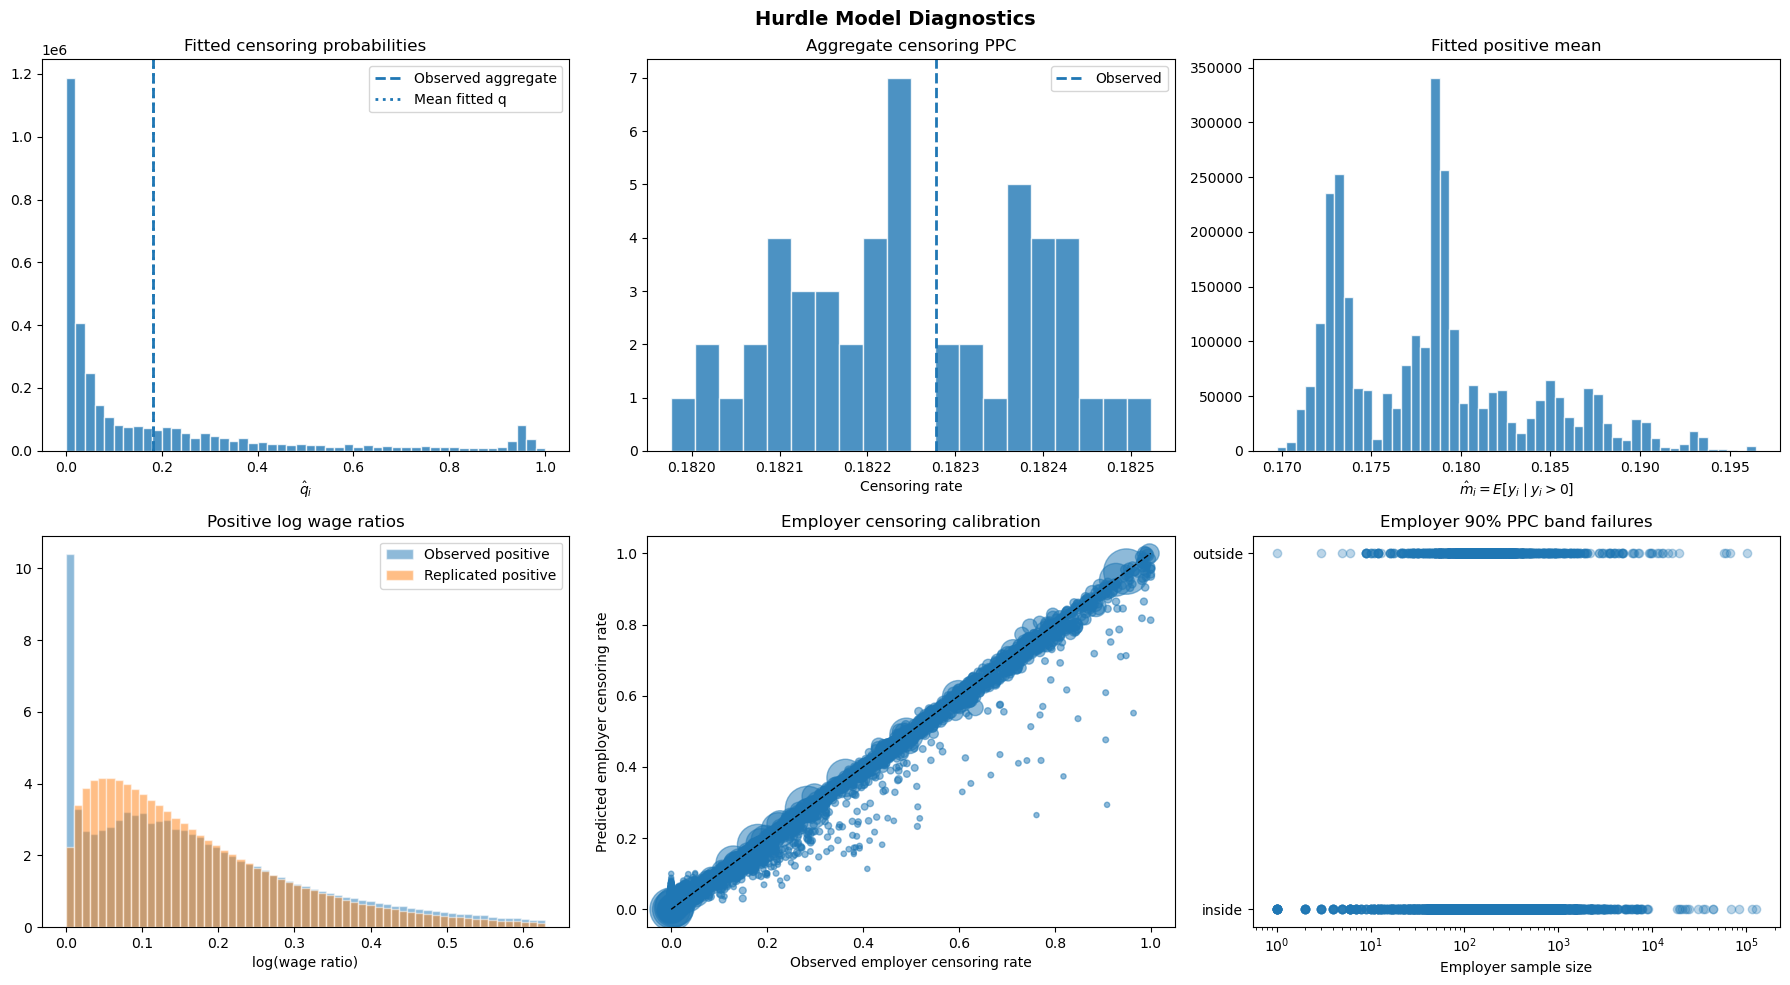

Baseline employers: 7276
Hurdle employers:   7276
Matched employers:  7276

Baseline vs hurdle comparison
------------------------------
Spearman baseline alpha vs hurdle positive-wage alpha: 0.5998
Spearman baseline alpha vs hurdle censoring alpha:     -0.6462
Bottom-30 baseline vs bottom-30 hurdle positive-wage overlap: 0.0%
Bottom-30 baseline vs top-30 hurdle suspicion overlap:        70.0%

Top hurdle suspicious employers:
                                          employer       n  obs_censor_rate  \
3127                                       infosys  114131         0.284138   
1085                             capgemini america   44212         0.129716   
2670                          grandison management    4044         0.997774   
6146                        tech mahindra americas   30710         0.599088   
2463                               fujitsu america    1173         0.987212   
1399                           cognizant worldwide     873         0.990836   
2752            

In [9]:
# =============================================================================
# RUN EVERYTHING
# =============================================================================

data_h = prepare_data_hurdle(df)

result_hurdle = fit_hurdle_model(
    data_h,
    logistic_C=1.0,
    gamma_alpha=1.0,
    max_iter=1000
)

ppc_h = ppc_hurdle_summary(result_hurdle, n_sim=50)
plot_hurdle_results(result_hurdle, ppc=ppc_h)

hurdle_effects = compare_hurdle_to_baseline_safe(
    result_hurdle=result_hurdle,
    result_baseline=result,
    df_baseline=df,
    top_n=30
)

In [10]:
# =============================================================================
# BOOTSTRAP PPC FOR HURDLE MODEL
# The above censoring parameters is plug-in, not accounting
# for parameter uncertainty.
# We use bootstrap to recalibrate the parameters.
# =============================================================================

def bootstrap_ppc_hurdle(
    df,
    B=100,
    n_rep_per_boot=1,
    logistic_C=1.0,
    gamma_alpha=1.0,
    max_iter=1000,
    random_state=123,
    min_employer_n=100,
):
    """
    Bootstrap predictive check for the hurdle model.

    For each bootstrap iteration:
        1. Resample rows of df with replacement.
        2. Refit the hurdle model on the bootstrap sample.
        3. Predict q_i and m_i on the ORIGINAL data.
        4. Simulate replicated data for the ORIGINAL observations.

    This gives a predictive distribution that includes parameter uncertainty.

    Important:
        This is a bootstrap predictive check, not a full Bayesian PPC.
    """

    rng = np.random.default_rng(random_state)

    # Original data object
    data_orig = prepare_data_hurdle(df)
    y_orig = data_orig["y"]
    cens_orig = data_orig["censored"]
    E_orig = data_orig["E"]
    n_orig = len(y_orig)
    n_E_orig = data_orig["N_E"]

    # Storage
    agg_censor_rates = []
    mean_positive_values = []
    emp_censor_reps = []

    successful_boots = 0

    for b in range(B):
        print(f"Bootstrap {b + 1}/{B}")

        # ---------------------------------------------------------------------
        # 1. Bootstrap rows
        # ---------------------------------------------------------------------
        boot_idx = rng.choice(np.arange(len(df)), size=len(df), replace=True)
        df_boot = df.iloc[boot_idx].copy()

        try:
            data_boot = prepare_data_hurdle(df_boot)

            if data_boot["censored"].mean() in [0, 1]:
                print("  skipped: all censored or all positive")
                continue

            # -----------------------------------------------------------------
            # 2. Refit model on bootstrap data
            # -----------------------------------------------------------------
            result_boot = fit_hurdle_model(
                data_boot,
                logistic_C=logistic_C,
                gamma_alpha=gamma_alpha,
                max_iter=max_iter,
                verbose=False
            )

            # -----------------------------------------------------------------
            # 3. Predict onto ORIGINAL data
            # -----------------------------------------------------------------
            # We need to build the original-data design matrix using the
            # bootstrap encoder. Unknown categories are ignored.
            X_orig, _ = make_design_matrix(
                data_orig,
                encoder=result_boot["encoder"],
                fit_encoder=False
            )

            q_orig = result_boot["logit_model"].predict_proba(X_orig)[:, 1]
            m_orig = result_boot["gamma_model"].predict(X_orig)
            m_orig = np.maximum(m_orig, EPS)

            shape = result_boot["shape"]

            # -----------------------------------------------------------------
            # 4. Simulate replicated original-sized datasets
            # -----------------------------------------------------------------
            for r in range(n_rep_per_boot):
                is_zero = rng.random(n_orig) < q_orig

                y_pos = rng.gamma(
                    shape=shape,
                    scale=m_orig / shape
                )

                y_rep = np.where(is_zero, 0.0, y_pos)

                agg_censor_rates.append((y_rep == 0).mean())
                mean_positive_values.append(y_rep[y_rep > 0].mean())

                emp_rates = np.zeros(n_E_orig)
                for e in range(n_E_orig):
                    idx_e = np.where(E_orig == e)[0]
                    if len(idx_e) == 0:
                        emp_rates[e] = np.nan
                    else:
                        emp_rates[e] = (y_rep[idx_e] == 0).mean()

                emp_censor_reps.append(emp_rates)

            successful_boots += 1

        except Exception as err:
            print(f"  skipped due to error: {err}")
            continue

    agg_censor_rates = np.array(agg_censor_rates)
    mean_positive_values = np.array(mean_positive_values)
    emp_censor_reps = np.array(emp_censor_reps)

    print("\nBootstrap PPC finished.")
    print(f"Successful bootstrap fits: {successful_boots}/{B}")

    return {
        "data_orig": data_orig,
        "agg_censor_rates": agg_censor_rates,
        "mean_positive_values": mean_positive_values,
        "emp_censor_reps": emp_censor_reps,
        "successful_boots": successful_boots,
    }


def summarize_bootstrap_ppc_hurdle(boot_ppc):
    data = boot_ppc["data_orig"]

    y = data["y"]
    censored = data["censored"]
    E = data["E"]
    employer_names = data["E_categories"]

    agg = boot_ppc["agg_censor_rates"]
    emp_reps = boot_ppc["emp_censor_reps"]

    print("\nBootstrap aggregate censoring PPC")
    print("----------------------------------")
    print(f"Observed censoring rate: {censored.mean():.4f}")
    print(f"Bootstrap predictive mean: {np.mean(agg):.4f}")
    print(
        "Bootstrap predictive 90% interval: "
        f"[{np.quantile(agg, 0.05):.4f}, {np.quantile(agg, 0.95):.4f}]"
    )

    n_E = data["N_E"]

    obs_emp_rate = np.zeros(n_E)
    pred_emp_mean = np.zeros(n_E)
    lo_emp = np.zeros(n_E)
    hi_emp = np.zeros(n_E)
    n_emp = np.zeros(n_E, dtype=int)
    outside = np.zeros(n_E, dtype=bool)

    for e in range(n_E):
        idx = np.where(E == e)[0]
        n_emp[e] = len(idx)

        obs_emp_rate[e] = censored[idx].mean()

        reps_e = emp_reps[:, e]
        reps_e = reps_e[np.isfinite(reps_e)]

        pred_emp_mean[e] = np.mean(reps_e)
        lo_emp[e] = np.quantile(reps_e, 0.05)
        hi_emp[e] = np.quantile(reps_e, 0.95)

        outside[e] = (
            obs_emp_rate[e] < lo_emp[e]
            or obs_emp_rate[e] > hi_emp[e]
        )

    outside_frac = outside.mean()

    print("\nBootstrap employer-level censoring PPC")
    print("---------------------------------------")
    print(f"Fraction outside 90% bands: {outside_frac:.4f}")

    emp_ppc = pd.DataFrame({
        "employer": employer_names,
        "n": n_emp,
        "obs_censor_rate": obs_emp_rate,
        "pred_censor_rate": pred_emp_mean,
        "lo_90": lo_emp,
        "hi_90": hi_emp,
        "outside_90": outside
    }).sort_values("n", ascending=False)

    return emp_ppc

In [11]:
boot_ppc = bootstrap_ppc_hurdle(
    df=df,
    B=100,
    n_rep_per_boot=1,
    logistic_C=1.0,
    gamma_alpha=1.0,
    max_iter=1000,
    random_state=123
)

emp_boot_ppc = summarize_bootstrap_ppc_hurdle(boot_ppc)

Bootstrap 1/100
Bootstrap 2/100
Bootstrap 3/100
Bootstrap 4/100
Bootstrap 5/100
Bootstrap 6/100
Bootstrap 7/100
Bootstrap 8/100
Bootstrap 9/100
Bootstrap 10/100
Bootstrap 11/100
Bootstrap 12/100
Bootstrap 13/100
Bootstrap 14/100
Bootstrap 15/100
Bootstrap 16/100
Bootstrap 17/100
Bootstrap 18/100
Bootstrap 19/100
Bootstrap 20/100
Bootstrap 21/100
Bootstrap 22/100
Bootstrap 23/100
Bootstrap 24/100
Bootstrap 25/100
Bootstrap 26/100
Bootstrap 27/100
Bootstrap 28/100
Bootstrap 29/100
Bootstrap 30/100
Bootstrap 31/100
Bootstrap 32/100
Bootstrap 33/100
Bootstrap 34/100
Bootstrap 35/100
Bootstrap 36/100
Bootstrap 37/100
Bootstrap 38/100
Bootstrap 39/100
Bootstrap 40/100
Bootstrap 41/100
Bootstrap 42/100
Bootstrap 43/100
Bootstrap 44/100
Bootstrap 45/100
Bootstrap 46/100
Bootstrap 47/100
Bootstrap 48/100
Bootstrap 49/100
Bootstrap 50/100
Bootstrap 51/100
Bootstrap 52/100
Bootstrap 53/100
Bootstrap 54/100
Bootstrap 55/100
Bootstrap 56/100
Bootstrap 57/100
Bootstrap 58/100
Bootstrap 59/100
Bootst

In [12]:
def plot_bootstrap_ppc_hurdle(boot_ppc, emp_boot_ppc):
    data = boot_ppc["data_orig"]
    censored = data["censored"]

    agg = boot_ppc["agg_censor_rates"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.hist(agg, bins=30, edgecolor="white", alpha=0.8)
    ax.axvline(censored.mean(), linestyle="--", linewidth=2, label="Observed")
    ax.set_title("Bootstrap aggregate censoring PPC")
    ax.set_xlabel("Censoring rate")
    ax.legend()

    ax = axes[1]
    show = emp_boot_ppc[emp_boot_ppc["n"] >= 20].copy()

    ax.scatter(
        show["obs_censor_rate"],
        show["pred_censor_rate"],
        s=np.sqrt(show["n"]) * 3,
        alpha=0.5
    )
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_title("Bootstrap employer censoring calibration")
    ax.set_xlabel("Observed employer censoring rate")
    ax.set_ylabel("Predicted employer censoring rate")

    plt.tight_layout()
    plt.show()

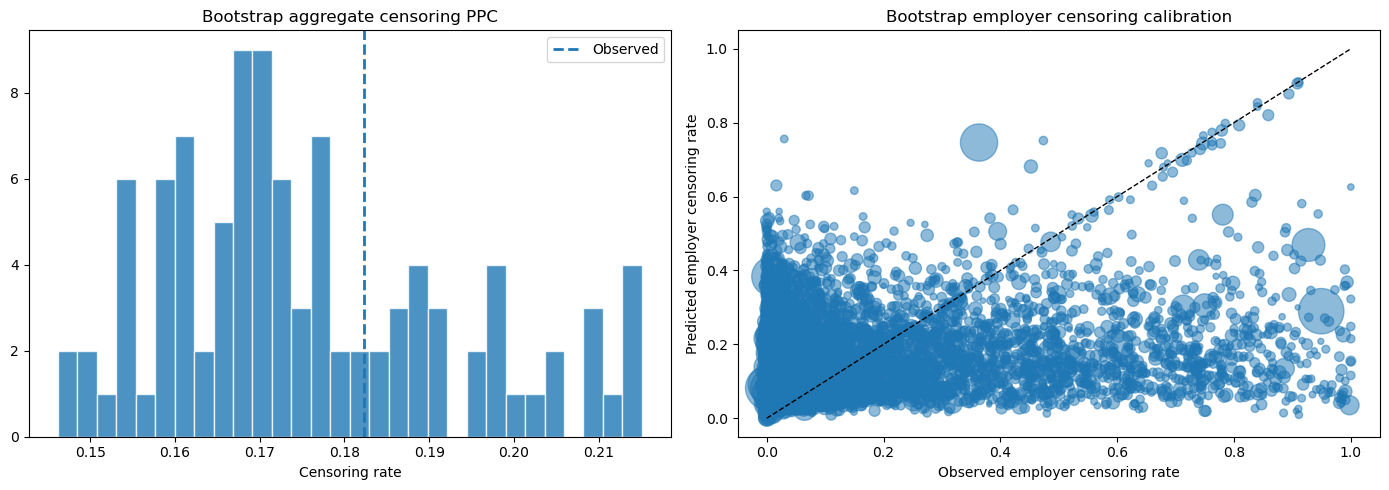

In [13]:
plot_bootstrap_ppc_hurdle(boot_ppc, emp_boot_ppc)

In [17]:
effects = extract_hurdle_effects(result_hurdle).copy()

top_bunching = effects.sort_values(
    "alpha_q_censoring",
    ascending=False
).head(30)

top_low_positive_wage = effects.sort_values(
    "alpha_y_positive_wage",
    ascending=True
).head(30)

print("Top threshold-bunching employers:")
print(top_bunching[[
    "employer",
    "n",
    "obs_censor_rate",
    "alpha_q_censoring",
    "alpha_y_positive_wage"
]])

print("\nTop low-positive-wage employers:")
print(top_low_positive_wage[[
    "employer",
    "n",
    "obs_censor_rate",
    "alpha_q_censoring",
    "alpha_y_positive_wage"
]])



def extract_hurdle_effects_v2(result):
    effects = extract_hurdle_effects(result).copy()

    z_q = (
        effects["alpha_q_censoring"]
        - effects["alpha_q_censoring"].mean()
    ) / (effects["alpha_q_censoring"].std() + EPS)

    z_y = (
        effects["alpha_y_positive_wage"]
        - effects["alpha_y_positive_wage"].mean()
    ) / (effects["alpha_y_positive_wage"].std() + EPS)

    effects["z_q_high_censoring"] = z_q
    effects["z_low_positive_wage"] = -z_y

    # Radical score: high if either high censoring or low positive wage
    effects["suspicion_additive"] = (
        effects["z_q_high_censoring"]
        + effects["z_low_positive_wage"]
    )

    # Stricter score: high only if both components are high
    #effects["suspicion_joint"] = (
    #    np.maximum(effects["z_q_high_censoring"], 0)
    #    * np.maximum(effects["z_low_positive_wage"], 0)
    #)

    # Another conservative version: bottleneck score
    #effects["suspicion_min"] = np.minimum(
    #    effects["z_q_high_censoring"],
    #    effects["z_low_positive_wage"]
    #)

    return effects


effects2 = extract_hurdle_effects_v2(result_hurdle)

effects2.sort_values("suspicion_additive", ascending=False).head(30)[[
    "employer",
    "n",
    "obs_censor_rate",
    "alpha_q_censoring",
    "alpha_y_positive_wage",
    "z_q_high_censoring",
    "z_low_positive_wage",
    "suspicion_additive"
]]



Top threshold-bunching employers:
                                          employer       n  obs_censor_rate  \
2670                          grandison management    4044         0.997774   
2463                               fujitsu america    1173         0.987212   
1399                           cognizant worldwide     873         0.990836   
2752                        harmony public schools     504         0.980159   
3091                               infobiz systems     646         0.993808   
2465                         fujitsu north america     284         1.000000   
3711                      little scholars arkansas      90         0.911111   
1912                                  dove schools     108         0.888889   
6434                                     tringapps     442         0.984163   
5377                                       samsara     254         0.980315   
5950                         strategic staffing it     255         0.980392   
4980              

,employer,n,obs_censor_rate,alpha_q_censoring,alpha_y_positive_wage,z_q_high_censoring,z_low_positive_wage,suspicion_additive
3127,infosys,114131,0.284138,1.402892,-9.470462e-03,0.848585,26.255624,27.104209
1085,capgemini america,44212,0.129716,0.445744,-7.015454e-03,0.269742,19.449432,19.719174
2670,grandison management,4044,0.997774,15.981258,-2.010691e-06,9.664983,0.005571,9.670554
6146,tech mahindra americas,30710,0.599088,2.623400,-1.697663e-03,1.586699,4.706548,6.293247
2463,fujitsu america,1173,0.987212,10.185981,-2.910511e-06,6.160237,0.008066,6.168303
1399,cognizant worldwide,873,0.990836,9.593157,-1.213058e-06,5.801721,0.003360,5.805081
2752,harmony public schools,504,0.980159,8.027826,-6.927179e-07,4.855073,0.001917,4.856991
3091,infobiz systems,646,0.993808,7.814193,-8.457961e-07,4.725877,0.002342,4.728219
2465,fujitsu north america,284,1.000000,6.871097,0.000000e+00,4.155531,-0.000003,4.155528
3711,little scholars arkansas,90,0.911111,6.842865,-6.828946e-07,4.138457,0.001890,4.140348
